# (28) Transl Kyoto: local dyna (best fit so far)

host = ```mach```, device = ```cuda:1```

**Motivation**:  <br>

- `speed` = 0.25
- `crop_size` = 32
- $T_\text{train} = 32$
- $T_\text{tbptt} = 32$

very higher $\beta = 16.0$

fwd: `u = 1`, `z = 5`

In [27]:
# HIDE CODE


project_name = '_TemporalSC'


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, project_name))
from figures.convergence import plot_convergence
from main.config_defaults import default_configs
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 1
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:1  ———  host: mach

## Make a model

In [3]:
model_type = 'poisson'
cfg_vae, cfg_tr = default_configs('Kyoto-wht+translate', model_type, 'ngd|lin')

cfg_vae['t_train'] = 32
cfg_vae['t_tbptt'] = 32
cfg_vae['kl_beta'] = 16.0

cfg_vae['latent_channels'] = 256
cfg_vae['latent_pixels'] = 8
cfg_vae['latent_stride'] = 3

cfg_vae['fwd_ker_u'] = 1
cfg_vae['fwd_ker_z'] = 5

cfg_vae['feeder_cfg'] = {'iters_per_epoch': 400, 'crop_size': 32, 'max_speed': 0.25, 'blur_sigma': 0.7}
cfg_vae['clamp_vals'] = {'u': (4.0,), 'du': (4.0,), 'dec': 1.15}  # the other best fit was 2.3

cfg_vae['recon_mode'] = 'prob'
cfg_vae['fit_sigma'] = True
cfg_vae['fit_dt'] = True

cfg_tr['lr'] = 5e-4
cfg_tr['epochs'] = 400
cfg_tr['batch_size'] = 100
# cfg_tr['grad_clip'] = 1_000
# cfg_tr['warmup_portion'] = 0.01

In [4]:
model = MODEL_CLASSES[model_type](CFG_CLASSES[model_type](**cfg_vae))
tr = Trainer(model, ConfigTrain(**cfg_tr), device=device)

tr.feeder_trn.n_iters

160000

+-------------+------------+
| Module Name | Num Params |
+-------------+------------+
|    IPVAE    |  1.7 Mil   |
|     ———     |    ———     |
|    layer    |  1.7 Mil   |
+-------------+------------+

poisson_Kyoto-wht+translate_t-(32,32)_b-16_kms-(256,8,3)_fwd-(1,5)_prob_<ngd|lin>
b100-ep400-lr(0.0005)_temp(0.05)_gr(200)_(2025_08_29,23:43)

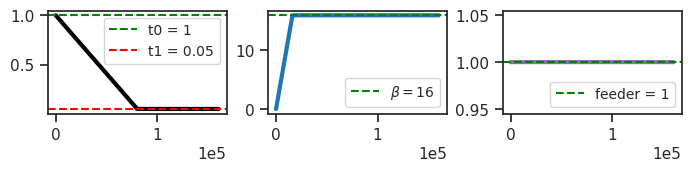

In [5]:
model.print()
tr.print()
tr.show_schedules()

In [6]:
model.layer.n_exp

tensor([10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10,
        10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10],
       device='cuda:1', dtype=torch.int32)

In [7]:
print(f"\n\n{tr.model.layer}\n\n{tr.model.layer.dec}\n")

PoissonLayer(latent_sz=(256, 8, 8), input_sz=(1, 32, 32), temp=1)

ConvDictionary(in_channels=256, out_channels=1, kernel_size=11, stride=3)

In [8]:
print_num_params(tr.model.layer)

+--------------+------------+
| Module Name  | Num Params |
+--------------+------------+
| PoissonLayer |  1.7 Mil   |
|     ———      |    ———     |
|    log_dt    |     1      |
|     dec      |   31.0 K   |
|   fwd_z.0    |  1.6 Mil   |
|   fwd_u.0    |   65.5 K   |
|    u_init    |    256     |
+--------------+------------+

In [9]:
print(f"\n\n{vars(tr.model.cfg)}\n\n{vars(tr.cfg)}\n")

{'prior_log_dist': 'uniform', 'clamp_prior': -4, 't_train': 32, 't_tbptt': 32, 'kl_beta': 16.0, 'latent_channels': 
256, 'latent_pixels': 8, 'latent_stride': 3, 'fwd_ker_u': 1, 'fwd_ker_z': 5, 'enc_type': 'ngd', 'dec_type': 'lin', 
'recon_mode': 'prob', 'dataset': 'Kyoto-wht+translate', 'dataset_name': 'Kyoto-wht', 'feeder': 'translate', 
'feeder_cfg': {'iters_per_epoch': 400, 'crop_size': 32, 'max_speed': 0.25, 'blur_sigma': 0.7, 'anneal_portion': 
0.0, 'shift_rescale': True, 'snap_to_pixel': False, 'mode': 'bilinear'}, 'input_sz': (1, 32, 32), 'latent_sz': 
(256, 8, 8), 'init_dist': 'normal', 'init_scale': 0.0001, 'clamp_vals': {'u': (4.0,), 'du': (4.0,), 'dec': 1.15}, 
'stochastic': True, 'optim_sigma': False, 'fit_sigma': True, 'fit_prior': True, 'fit_dt': True, 'seed': 0, 
'track_stats': False, 'base_dir': '/home/hadi/Projects/TemporalSC', 'data_dir': '/home/hadi/Datasets', 'runs_dir': 
'/home/hadi/Projects/TemporalSC/runs/poisson_Kyoto-wht+translate_t-(32,32)_b-16_kms-(256,8,3)_fwd-(1,5)_prob_<ngd|l
in>', 'mods_dir': 
'/home/hadi/Projects/TemporalSC/models/poisson_Kyoto-wht+translate_t-(32,32)_b-16_kms-(256,8,3)_fwd-(1,5)_prob_<ngd
|lin>', 'results_dir': '/home/hadi/Projects/TemporalSC/results'}

{'lr': 0.0005, 'epochs': 400, 'batch_size': 100, 'dataset_kws': None, 'warm_restart': 0, 'warmup_portion': 0.005, 
'optimizer': 'adamax_fast', 'optimizer_kws': {'weight_decay': 0.001, 'betas': (0.9, 0.999), 'eps': 1e-08}, 
'scheduler_type': 'cosine', 'scheduler_kws': {'T_max': 398.0, 'eta_min': 1e-06}, 'ema_rate': None, 'grad_clip': 
200, 'chkpt_freq': 50, 'eval_freq': 20, 'log_freq': 10, 'kl_beta_min': 0.0001, 'kl_const_portion': 0.001, 
'kl_anneal_portion': 0.1, 'temp_anneal_portion': 0.5, 'temp_anneal_type': 'lin', 'temp_start': 1.0, 'temp_stop': 
0.05}

In [10]:
comment = '_'.join([
    f"fwd:u{tr.model.cfg.fwd_ker_u}+z{tr.model.cfg.fwd_ker_z}",
    f"fit:{'dt' if tr.model.cfg.fit_dt else ''}+{'sig' if tr.model.cfg.fit_sigma else ''}",
    f"maxspeed-{tr.feeder_trn.max_speed}",
])
print(comment)

fwd:u1+z5_fit:dt+sig_maxspeed-0.25

In [11]:
tr.train(comment=comment)

wandb: ERROR Failed to detect the name of this notebook. You can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.


Warning: Could not save code info: Reference at 'refs/heads/main' does not exist

Warning: Could not save notebook info: Can't identify the notebook path.

epoch # 400, avg loss: -138.476: 100%|████| 400/400 [34:49:45<00:00, 313.46s/it]


In [24]:
print(model.layer.n_exp)

tensor([14, 29, 43, 44, 43, 43, 44, 44, 44, 44, 44, 44, 44, 44, 44, 44, 44, 44,
        44, 44, 44, 44, 44, 44, 44, 44, 44, 43, 44, 44, 44, 43],
       device='cuda:1', dtype=torch.int32)

100%|███████████████████████████████| 200/200 [10:51<00:00,  3.26s/it]


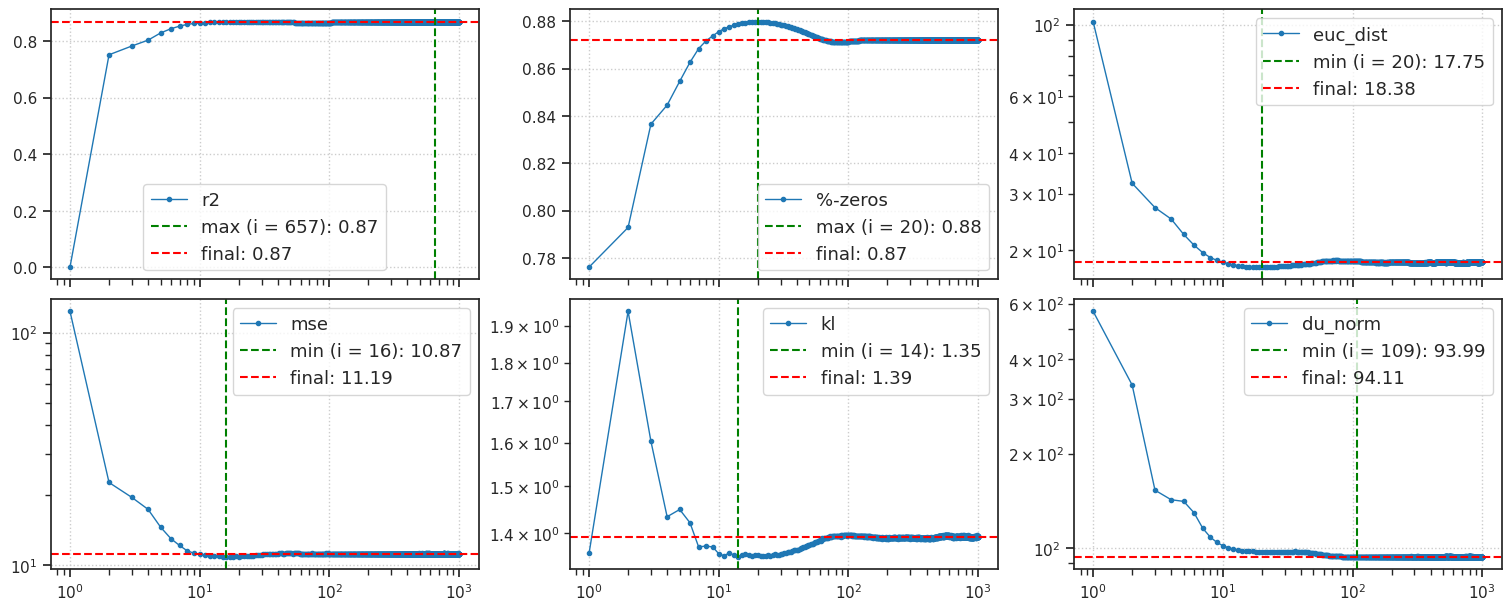

CPU times: user 10min 50s, sys: 2.32 s, total: 10min 53s
Wall time: 10min 52s


In [26]:
%%time

results = tr.analysis('vld', t_total=1000, n_data_batches=200)
_ = plot_convergence(results=results, color='C0')

In [28]:
print(model.layer.n_exp)

tensor([14, 29, 43, 44, 43, 43, 44, 44, 44, 44, 44, 44, 44, 44, 44, 44, 44, 44,
        44, 44, 44, 44, 44, 44, 44, 44, 44, 43, 44, 44, 44, 43],
       device='cuda:1', dtype=torch.int32)

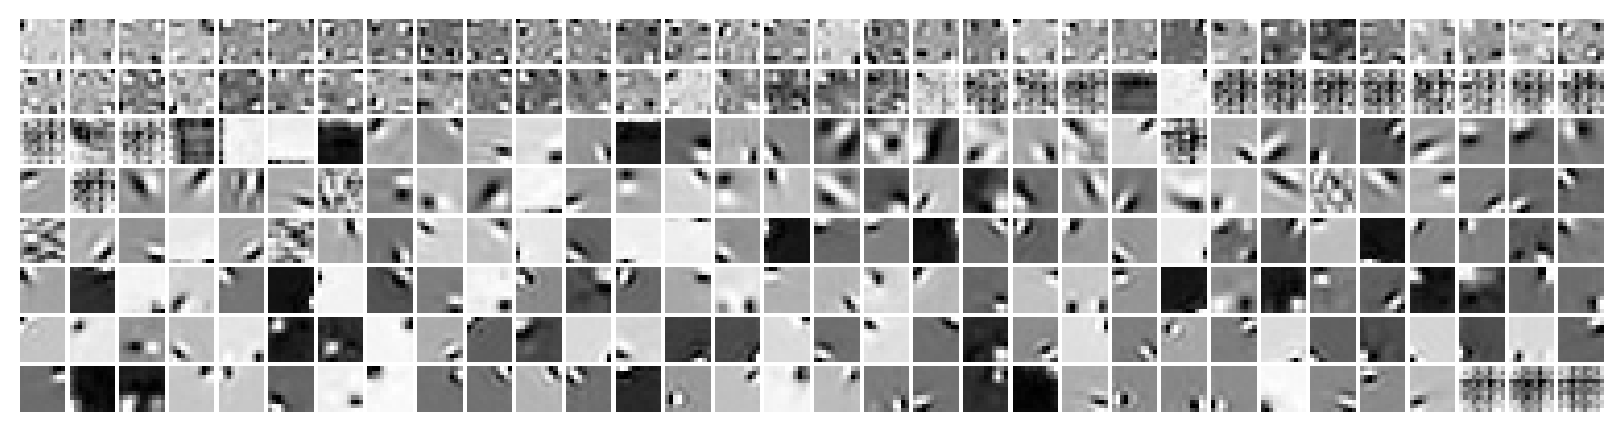

In [29]:
u0 = tonp(tr.model.layer.u_init[0].squeeze())
tr.model.show(order=np.argsort(u0));

In [30]:
output = tr.xtract_ftr(
    data='vld',
    t_total=32,
    save_freq=1,
    data_batch_sz=50,
    n_data_batches=1,
    return_recon=True,
    verbose=False,
)

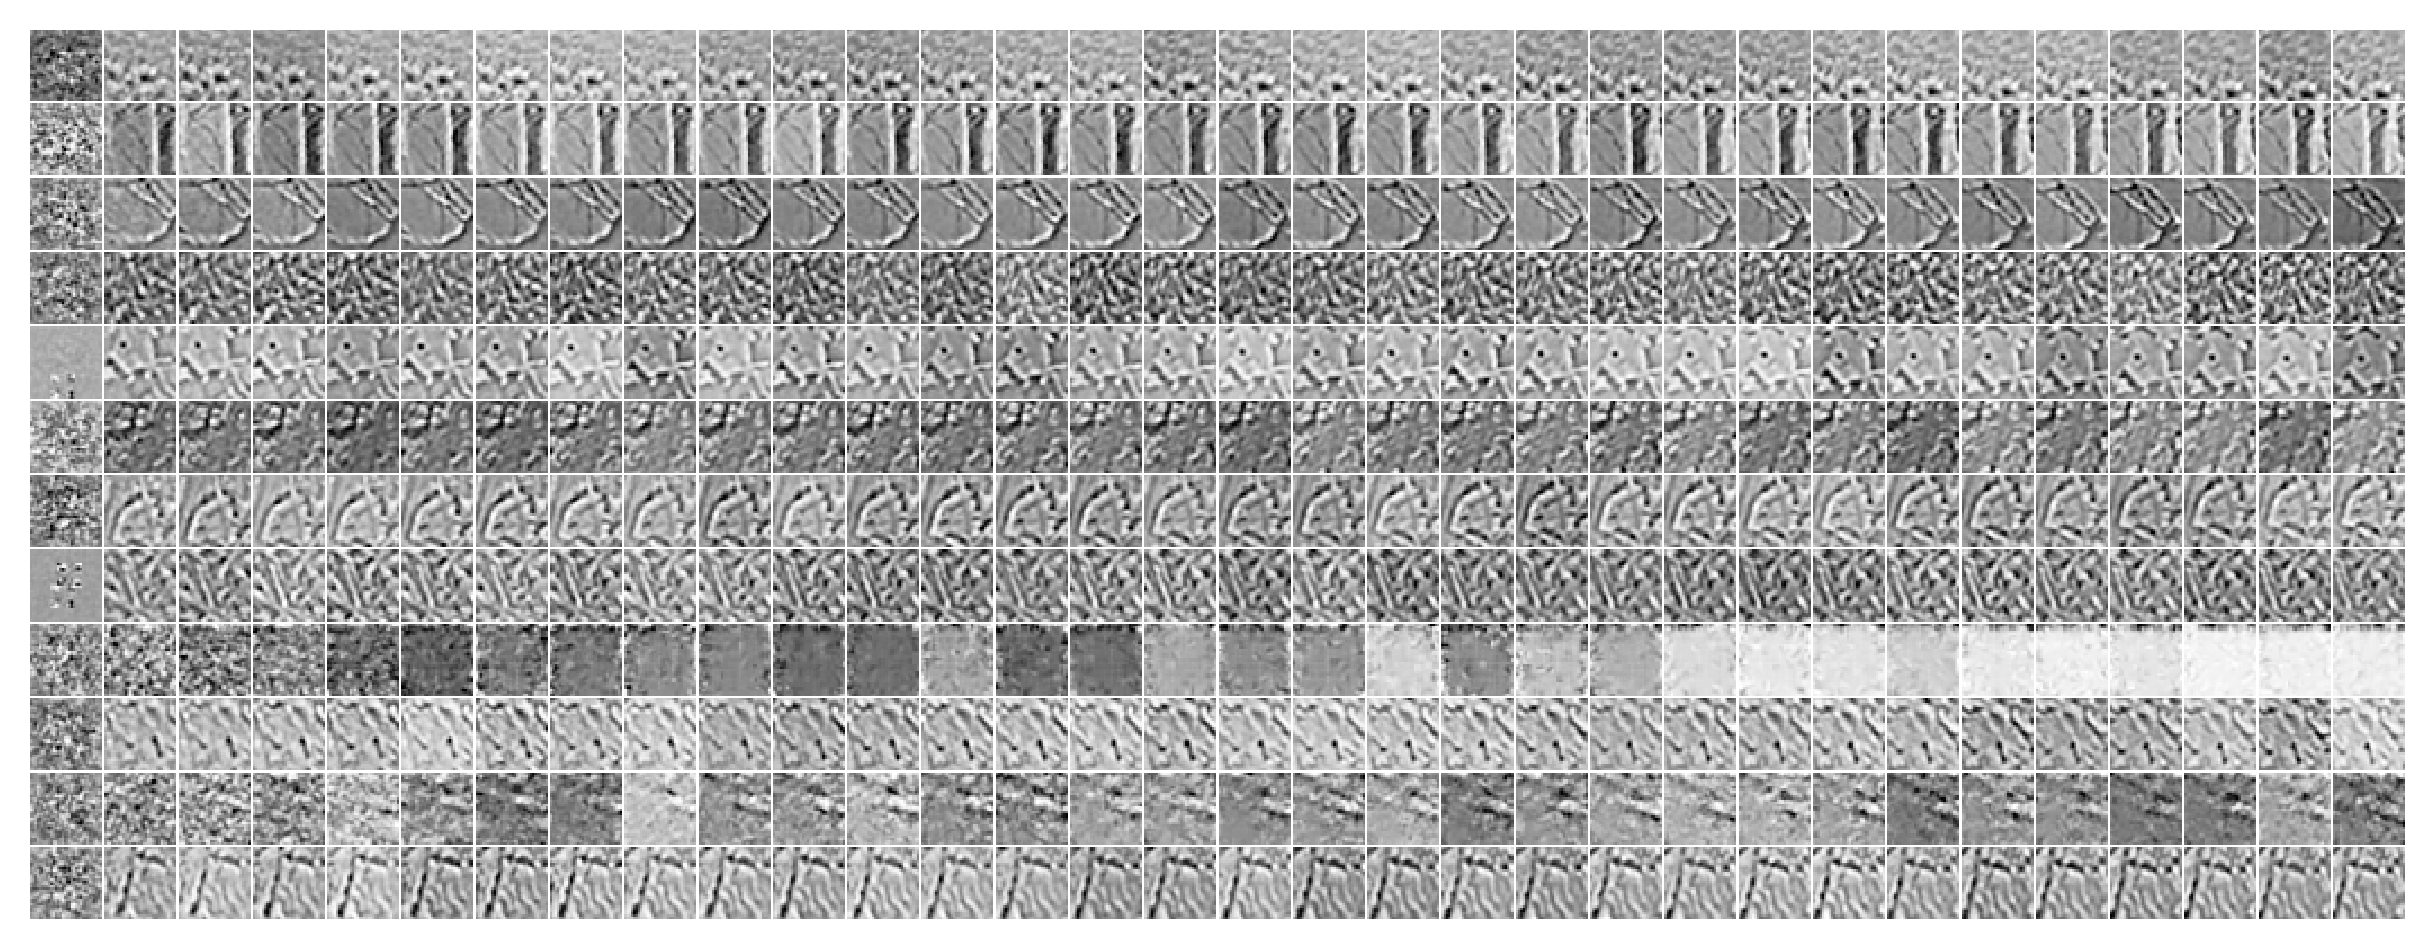

In [31]:
num = 12
x2p = output['recon'][:num].reshape(-1, *tr.model.cfg.input_sz[-2:])
_ = plot_weights(x2p, method='min-max', nrows=num, dpi=300)

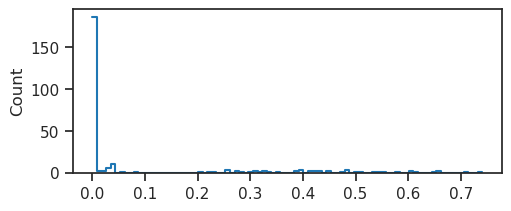

In [34]:
log_bias = tonp(tr.model.layer.log_bias.squeeze())
bias = np.exp(log_bias)

fig, ax = create_figure(1, 1, (5, 2))
histplot(bias.ravel())
plt.show()

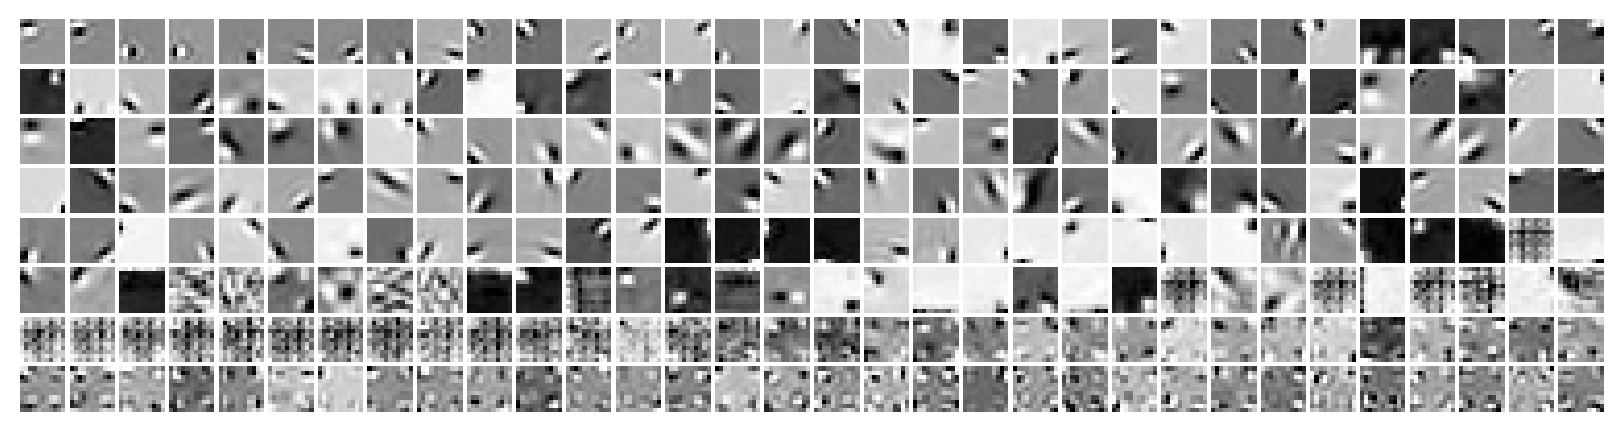

In [35]:
tr.model.show(order=np.argsort(bias));

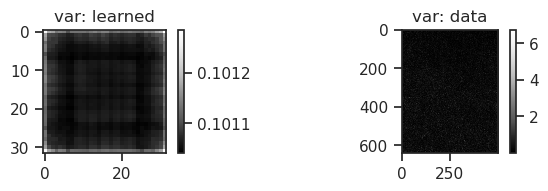

learned inner learning rates (dt):

(tensor([0.0534], device='cuda:1', grad_fn=<ExpBackward0>),)

In [36]:
# get var: learned & data
log_sigma = tonp(tr.model.layer.get_dec_log_sigma().squeeze())
var_init = (np.exp(2 * log_sigma)).reshape(tr.model.cfg.input_sz)
var_data = tonp(tr.feeder_vld.x.var(dim=0))

# plot
fig, axes =  create_figure(1, 2, (6.2, 1.8))
im = axes[0].imshow(var_init.mean(0), cmap='Greys_r')
plt.colorbar(im, ax=axes[0])
im = axes[1].imshow(var_data.mean(0), cmap='Greys_r')
plt.colorbar(im, ax=axes[1])

axes[0].set_title('var: learned')
axes[1].set_title('var: data')

plt.show()

# print dt
lr_inner = tuple(dt.exp() for dt in tr.model.layer.log_dt)
print(f"learned inner learning rates (dt):\n\n{lr_inner}\n")

In [37]:
print(sp_stats.pearsonr(u0.ravel(), log_bias.ravel()))

PearsonRResult(statistic=-0.9208215624643198, pvalue=7.253508340508011e-106)